<a href="https://colab.research.google.com/github/SANGHATI23/neurofhir-qc/blob/main/24B_NeuroFHIR_TRACE_FINAL_Landmark_CrossFit_Attenuation_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# NeuroFHIR-TRACE — Notebook 24B-REAL-FINAL-STRENGTHENING-V2
## Strict 12-Month Landmark + Cross-Fitted Technical Shifts + Generic Attenuation Controls

This notebook addresses three reviewer-facing methodological concerns before the ICHI submission is frozen.

### Fix 1 — Prospective landmark prediction

The analysis includes only participants who remain **MCI at the 12-month landmark**. MRI change observed from baseline to 12 months is then used to predict **future conversion after the landmark through 36 months from baseline**.

Participants with dementia on/before the landmark or within 30 days after the landmark are excluded.

### Fix 2 — Cross-fitted technical perturbations

For every outer patient fold:

- TRACE Q90/Q95 reliability envelopes are estimated from **training repeat subjects only**.
- Technical perturbation ratios are sampled from a **held-out repeat-subject fold**.
- No same-day repeat pair contributes to both gate calibration and perturbation generation in the same evaluation fold.

### Fix 3 — Generic attenuation controls

The notebook compares TRACE against generic attenuation of Model B's incremental imaging contribution:

- **G25:** retain 25% of the Model-B imaging contribution.
- **G50:** retain 50%.
- **G75:** retain 75%.

These controls create an explicit robustness–information tradeoff. TRACE C2 should be interpreted against this attenuation frontier rather than against raw Model B alone.

### Primary endpoint

Mean absolute downstream probability movement under cross-fitted empirical technical shifts.

### Guardrail

This is a reliability/propagation-control study. It does not establish clinical safety, diagnostic superiority, or biological ground truth.


### V2 strengthening

This version adds three safeguards before the final run:

1. **Full-pair covariance-preserving perturbations:** one held-out same-day repeat pair is sampled per downstream subject, and its complete multi-feature ratio vector is applied with one shared orientation. This preserves observed cross-feature technical covariance.
2. **Outer-test RID exclusion:** repeat records belonging to downstream outer-test subjects are removed from both threshold calibration and the held-out perturbation bank for that outer fold.
3. **Static feature-reliability baseline:** a global, outcome-blind reliability-weighted model is added to distinguish patient-specific TRACE control from generic feature-level reliability weighting.


In [33]:

from pathlib import Path
import json
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")

SEED = 2027
SHIFT_REPS = 100
BOOT_REPS = 2000
N_FOLDS = 5

OUTDIR = Path("trace_24b_final_strengthening_outputs")
OUTDIR.mkdir(exist_ok=True)

print("Output directory:", OUTDIR.resolve())


Output directory: /content/trace_24b_final_strengthening_outputs



## 1. Upload two private files through the Colab Files pane

Upload:

1. `TRACE_ADNI1_landmark12_REAL.csv`
2. `TRACE_ADNI1_repeat_pairs_REAL.csv`

Do **not** use the Python upload widget. Wait until both files are visible under `/content`.


In [34]:

EXPECTED_LANDMARK = "TRACE_ADNI1_landmark12_REAL.csv"
EXPECTED_REPEAT = "TRACE_ADNI1_repeat_pairs_REAL.csv"

SEARCH_DIRS = [Path("/content"), Path.cwd(), Path("/mnt/data")]

def find_file(expected_name):
    stem = Path(expected_name).stem
    suffix = Path(expected_name).suffix.lower()

    for d in SEARCH_DIRS:
        p = d / expected_name
        if p.exists():
            return p

    candidates = []
    for d in SEARCH_DIRS:
        if d.exists():
            candidates.extend(
                p for p in d.glob(f"{stem}*{suffix}") if p.is_file()
            )

    if not candidates:
        return None

    return sorted(
        candidates,
        key=lambda p: p.stat().st_mtime,
        reverse=True
    )[0]

LANDMARK_PATH = find_file(EXPECTED_LANDMARK)
REPEAT_PATH = find_file(EXPECTED_REPEAT)

missing = []
if LANDMARK_PATH is None:
    missing.append(EXPECTED_LANDMARK)
if REPEAT_PATH is None:
    missing.append(EXPECTED_REPEAT)

if missing:
    raise FileNotFoundError(
        "Missing: " + ", ".join(missing) +
        ". Upload both through Colab's left Files pane."
    )

df = pd.read_csv(LANDMARK_PATH)
rep = pd.read_csv(REPEAT_PATH)

print("Landmark cohort:", LANDMARK_PATH, df.shape)
print("Repeat pairs:", REPEAT_PATH, rep.shape)


Landmark cohort: /content/TRACE_ADNI1_landmark12_REAL.csv (199, 70)
Repeat pairs: /content/TRACE_ADNI1_repeat_pairs_REAL.csv (90, 51)


## 2. Cohort and schema audit

In [35]:

FEATURES = [
    "LHIPPOC",
    "RHIPPOC",
    "LENTORHIN",
    "RENTORHIN",
    "LMIDTEMP",
    "RMIDTEMP",
    "VENTRICLES",
]
ALL_MRI = FEATURES + ["ICV"]

CLINICAL = [
    "AGE_LANDMARK",
    "SEX_FEMALE",
    "EDUCATION_YEARS",
    "MMSE_LANDMARK",
    "CDR_LANDMARK",
    "FAQ_LANDMARK",
]

ACQ_TYPE = "SAME_DAY_DIFFERENT_ACQUISITION"

required = (
    ["RID", "LABEL_12_36",
     "BL_OVERALLQC", "M12_OVERALLQC",
     "BL_TEMPQC", "M12_TEMPQC",
     "BL_VENTQC", "M12_VENTQC"]
    + CLINICAL
    + [f"BL_{f}" for f in ALL_MRI]
    + [f"M12_{f}" for f in ALL_MRI]
)

missing_cols = [c for c in required if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing landmark columns: {missing_cols}")

rep_required = (
    ["RID", "REPEAT_TYPE"]
    + [f"{f}_1" for f in ALL_MRI]
    + [f"{f}_2" for f in ALL_MRI]
    + [f"PCT_DIFF_{f}" for f in ALL_MRI]
)

missing_rep = [c for c in rep_required if c not in rep.columns]
if missing_rep:
    raise ValueError(f"Missing repeat columns: {missing_rep}")

df["y"] = df["LABEL_12_36"].map({
    "sMCI12": 0,
    "pMCI12": 1,
})

if df["y"].isna().any():
    raise ValueError("Unexpected LABEL_12_36 values.")

acq = rep.loc[rep["REPEAT_TYPE"] == ACQ_TYPE].copy()

print("Eligible landmark subjects:", len(df))
print(df["LABEL_12_36"].value_counts())
print("\nSame-day acquisition repeat pairs:", len(acq))
print("Same-day acquisition repeat subjects:", acq["RID"].nunique())

print("\nClinical availability:")
for c in CLINICAL:
    print(c, int(pd.to_numeric(df[c], errors="coerce").notna().sum()), "/", len(df))


Eligible landmark subjects: 199
LABEL_12_36
sMCI12    123
pMCI12     76
Name: count, dtype: int64

Same-day acquisition repeat pairs: 75
Same-day acquisition repeat subjects: 60

Clinical availability:
AGE_LANDMARK 199 / 199
SEX_FEMALE 199 / 199
EDUCATION_YEARS 199 / 199
MMSE_LANDMARK 197 / 199
CDR_LANDMARK 195 / 199
FAQ_LANDMARK 195 / 199



## 3. Signed baseline→12-month MRI change

\[
\Delta_f = 100 \times \frac{M12_f - BL_f}{|BL_f|}
\]

The biological downstream predictors exclude ICV. ICV is retained as a technical stability anchor.


In [36]:

for f in ALL_MRI:
    bl = pd.to_numeric(df[f"BL_{f}"], errors="coerce")
    m12 = pd.to_numeric(df[f"M12_{f}"], errors="coerce")

    signed = 100.0 * (m12 - bl) / bl.abs()
    signed = signed.replace([np.inf, -np.inf], np.nan)

    df[f"{f}_SIGNED_PCT"] = signed
    df[f"{f}_ABS_PCT"] = signed.abs()

print(df[[f"{f}_SIGNED_PCT" for f in FEATURES]].describe().T)


                       count      mean        std        min        25%  \
LHIPPOC_SIGNED_PCT     199.0 -2.787691   5.734772 -44.034978  -6.021959   
RHIPPOC_SIGNED_PCT     199.0 -2.466741   5.217854 -12.997839  -5.884786   
LENTORHIN_SIGNED_PCT   199.0 -0.046190  21.704467 -54.697701 -13.868750   
RENTORHIN_SIGNED_PCT   199.0 -0.912137  21.768930 -61.293260 -13.716447   
LMIDTEMP_SIGNED_PCT    199.0 -2.541575   5.948771 -22.279622  -5.747882   
RMIDTEMP_SIGNED_PCT    199.0 -1.991929   4.755447 -15.851914  -4.933552   
VENTRICLES_SIGNED_PCT  199.0  6.664000   6.500698  -8.921262   3.117065   

                            50%       75%         max  
LHIPPOC_SIGNED_PCT    -2.646130  0.377192   13.638325  
RHIPPOC_SIGNED_PCT    -2.662828  0.228754   25.857275  
LENTORHIN_SIGNED_PCT  -3.004292  9.107178  111.390887  
RENTORHIN_SIGNED_PCT  -2.995720  9.120639   96.322657  
LMIDTEMP_SIGNED_PCT   -2.657602  1.154982   30.365297  
RMIDTEMP_SIGNED_PCT   -1.818485  0.993439   11.567466  
VENTRIC


## 4. Build fixed repeat-subject folds

The same repeat-subject fold assignment is reused across the outer evaluation folds.

For outer fold `k`:

- repeat fold `k` = **held-out perturbation bank**
- repeat folds other than `k` = **TRACE threshold calibration**

This creates strict within-fold separation between threshold construction and shift generation.


In [37]:

repeat_subjects = np.array(sorted(acq["RID"].dropna().unique()))
local_rng = np.random.default_rng(SEED)
local_rng.shuffle(repeat_subjects)

repeat_folds = np.array_split(repeat_subjects, N_FOLDS)

repeat_fold_map = {}
for k, arr in enumerate(repeat_folds):
    for rid in arr:
        repeat_fold_map[rid] = k

acq["REPEAT_FOLD"] = acq["RID"].map(repeat_fold_map)

print(acq.groupby("REPEAT_FOLD").agg(
    subjects=("RID", "nunique"),
    pairs=("RID", "size"),
))


             subjects  pairs
REPEAT_FOLD                 
0                  12     19
1                  12     14
2                  12     15
3                  12     14
4                  12     13


## 5. Fold-specific TRACE calibration

In [38]:

def calibrate_thresholds(rep_train):
    rows = []

    for f in ALL_MRI:
        vals = pd.to_numeric(
            rep_train[f"PCT_DIFF_{f}"],
            errors="coerce"
        ).dropna().to_numpy()

        rows.append({
            "feature": f,
            "q50": float(np.percentile(vals, 50)),
            "q90": float(np.percentile(vals, 90)),
            "q95": float(np.percentile(vals, 95)),
            "n": int(len(vals)),
        })

    return pd.DataFrame(rows).set_index("feature")



def make_ratio_vector_bank(rep_shift):
    """Build complete multi-feature ratio vectors from held-out repeat pairs.

    One row = one real same-day repeat pair.  All MRI feature ratios remain
    linked so sampled perturbations preserve observed cross-feature covariance.
    """
    rows = []

    for _, r in rep_shift.iterrows():
        item = {}
        valid = True

        for f in ALL_MRI:
            a = pd.to_numeric(pd.Series([r[f"{f}_1"]]), errors="coerce").iloc[0]
            b = pd.to_numeric(pd.Series([r[f"{f}_2"]]), errors="coerce").iloc[0]

            if not (np.isfinite(a) and np.isfinite(b) and a > 0 and b > 0):
                valid = False
                break

            ratio = b / a

            if not (np.isfinite(ratio) and ratio > 0):
                valid = False
                break

            item[f] = float(ratio)

        if valid:
            item["RID"] = r["RID"]
            rows.append(item)

    bank = pd.DataFrame(rows)

    if len(bank) < 5:
        raise ValueError(
            f"Too few complete held-out same-day ratio vectors: {len(bank)}"
        )

    return bank


## 6. Empirical held-out technical shifts

In [39]:

def apply_empirical_shift(d, ratio_vector_bank, local_rng):
    """Apply one real multi-feature perturbation vector per subject.

    A single repeat-pair row is sampled for each downstream subject.  One
    orientation (pair direction or inverse) is then shared across all features,
    preserving the observed within-pair cross-feature dependence structure.
    """
    out = d.copy()

    sampled_idx = local_rng.integers(
        0,
        len(ratio_vector_bank),
        size=len(out)
    )

    sampled = ratio_vector_bank.iloc[sampled_idx].reset_index(drop=True)

    invert = local_rng.random(len(out)) < 0.5

    for f in ALL_MRI:
        ratios = sampled[f].to_numpy(dtype=float)
        ratios = np.where(invert, 1.0 / ratios, ratios)

        bl = pd.to_numeric(
            out[f"BL_{f}"],
            errors="coerce"
        ).to_numpy(dtype=float)

        m12 = pd.to_numeric(
            out[f"M12_{f}"],
            errors="coerce"
        ).to_numpy(dtype=float)

        shifted_m12 = m12 * ratios
        shifted_signed = 100.0 * (shifted_m12 - bl) / np.abs(bl)

        out[f"{f}_SHIFTED_SIGNED_PCT"] = shifted_signed
        out[f"{f}_SHIFTED_ABS_PCT"] = np.abs(shifted_signed)

    return out


## 7. Model construction

In [40]:

def static_reliability_weights(thresholds):
    """Outcome-blind global feature reliability weights.

    Features at or below the median biological-feature Q90 receive weight 1.
    Less repeatable features receive median_Q90 / feature_Q90.
    These weights are fixed for every patient within the fold.
    """
    q90 = thresholds.loc[FEATURES, "q90"].astype(float)
    reference = float(np.median(q90))

    weights = {
        f: float(min(1.0, reference / float(q90.loc[f])))
        for f in FEATURES
    }

    return weights


def feature_tables(d, thresholds):
    XA = d[CLINICAL].copy()

    raw = pd.DataFrame(index=d.index)
    c1 = pd.DataFrame(index=d.index)
    c2 = pd.DataFrame(index=d.index)
    static = pd.DataFrame(index=d.index)

    static_w = static_reliability_weights(thresholds)

    for f in FEATURES:
        vals = pd.to_numeric(
            d[f"{f}_SIGNED_PCT"],
            errors="coerce"
        )

        state = d[f"{f}_TRACE_STATE"].astype(str)

        weight = pd.to_numeric(
            d[f"{f}_TRACE_WEIGHT"],
            errors="coerce"
        )

        raw[f"{f}_RAW"] = vals

        c1[f"{f}_C1"] = vals.where(
            state.eq("TRUSTED"),
            np.nan
        )

        c2[f"{f}_C2"] = vals * weight

        static[f"{f}_STATIC"] = vals * static_w[f]

    return {
        "A": XA,
        "B": pd.concat([XA, raw], axis=1),
        "STATIC": pd.concat([XA, static], axis=1),
        "C1": pd.concat([XA, c1], axis=1),
        "C2": pd.concat([XA, c2], axis=1),
    }


def shifted_feature_tables(d, thresholds):
    XA = d[CLINICAL].copy()

    raw = pd.DataFrame(index=d.index)
    c1 = pd.DataFrame(index=d.index)
    c2 = pd.DataFrame(index=d.index)
    static = pd.DataFrame(index=d.index)

    static_w = static_reliability_weights(thresholds)

    for f in FEATURES:
        vals = pd.to_numeric(
            d[f"{f}_SHIFTED_SIGNED_PCT"],
            errors="coerce"
        )

        state = d[f"{f}_SHIFTED_TRACE_STATE"].astype(str)

        weight = pd.to_numeric(
            d[f"{f}_SHIFTED_TRACE_WEIGHT"],
            errors="coerce"
        )

        raw[f"{f}_RAW"] = vals

        c1[f"{f}_C1"] = vals.where(
            state.eq("TRUSTED"),
            np.nan
        )

        c2[f"{f}_C2"] = vals * weight

        static[f"{f}_STATIC"] = vals * static_w[f]

    return {
        "A": XA,
        "B": pd.concat([XA, raw], axis=1),
        "STATIC": pd.concat([XA, static], axis=1),
        "C1": pd.concat([XA, c1], axis=1),
        "C2": pd.concat([XA, c2], axis=1),
    }



## 8. Strict outer-fold experiment

All downstream models use identical outer patient folds.

Within each fold:

1. thresholds come from repeat-training subjects;
2. the shift bank comes from disjoint held-out repeat subjects;
3. TRACE states are computed using only the fold-specific thresholds;
4. the held-out patient fold is perturbed 100 times using the held-out technical bank.

Generic attenuation controls are generated from the clinical Model A and raw-imaging Model B predictions:

\[
p_{G_\gamma} = p_A + \gamma(p_B-p_A)
\]

for \(\gamma \in \{0.25,0.50,0.75\}\).

This uniformly attenuates Model B's incremental imaging contribution without using patient-specific reliability.


In [41]:
# ============================================================
# 8. STRICT OUTER-FOLD EXPERIMENT — SELF-CONTAINED FIXED VERSION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold


# ============================================================
# BASIC CONSTANTS
# ============================================================

SEED = 2027
SHIFT_REPS = 100
N_FOLDS = 5

FEATURES = [
    "LHIPPOC",
    "RHIPPOC",
    "LENTORHIN",
    "RENTORHIN",
    "LMIDTEMP",
    "RMIDTEMP",
    "VENTRICLES",
]

ALL_MRI = FEATURES + ["ICV"]

CLINICAL = [
    "AGE_LANDMARK",
    "SEX_FEMALE",
    "EDUCATION_YEARS",
    "MMSE_LANDMARK",
    "CDR_LANDMARK",
    "FAQ_LANDMARK",
]


# ============================================================
# SAFETY CHECKS
# ============================================================

if "df" not in globals():
    raise RuntimeError("df is missing. Run Sections 1–3 first.")

if "acq" not in globals():
    raise RuntimeError("acq is missing. Run repeat-data setup first.")

if "y" not in globals():
    df["y"] = df["LABEL_12_36"].map({
        "sMCI12": 0,
        "pMCI12": 1
    })

    y = df["y"].to_numpy(dtype=int)


# ============================================================
# REPEAT FOLD ASSIGNMENT
# ============================================================

if "REPEAT_FOLD" not in acq.columns:

    repeat_subjects = np.array(
        sorted(
            acq["RID"]
            .dropna()
            .unique()
        )
    )

    rng_repeat = np.random.default_rng(SEED)

    rng_repeat.shuffle(
        repeat_subjects
    )

    repeat_folds = np.array_split(
        repeat_subjects,
        N_FOLDS
    )

    repeat_fold_map = {}

    for k, arr in enumerate(repeat_folds):

        for rid in arr:

            repeat_fold_map[rid] = k

    acq["REPEAT_FOLD"] = (
        acq["RID"]
        .map(repeat_fold_map)
    )


# ============================================================
# MODEL
# ============================================================

def make_model():

    return Pipeline([

        (
            "imputer",

            SimpleImputer(
                strategy="median",
                add_indicator=True,
                keep_empty_features=True
            )
        ),

        (
            "scaler",
            StandardScaler()
        ),

        (
            "clf",

            LogisticRegressionCV(
                Cs=[0.01, 0.1, 1.0, 10.0],
                cv=3,
                scoring="neg_log_loss",
                penalty="l2",
                solver="liblinear",
                max_iter=5000
            )
        )
    ])


# ============================================================
# CALIBRATE REPEAT THRESHOLDS
# ============================================================

def calibrate_thresholds(rep_train):

    rows = []

    for f in ALL_MRI:

        col = f"PCT_DIFF_{f}"

        vals = pd.to_numeric(
            rep_train[col],
            errors="coerce"
        ).dropna().to_numpy()

        if len(vals) < 5:

            raise ValueError(
                f"Too few calibration observations for {f}: {len(vals)}"
            )

        rows.append({

            "feature": f,

            "q50":
                float(
                    np.percentile(
                        vals,
                        50
                    )
                ),

            "q90":
                float(
                    np.percentile(
                        vals,
                        90
                    )
                ),

            "q95":
                float(
                    np.percentile(
                        vals,
                        95
                    )
                ),

            "n":
                int(
                    len(vals)
                )
        })

    return (
        pd.DataFrame(rows)
        .set_index("feature")
    )


# ============================================================
# COMPLETE MULTI-FEATURE SHIFT BANK
# ============================================================

def make_ratio_vector_bank(rep_shift):

    rows = []

    for _, r in rep_shift.iterrows():

        item = {}

        valid = True

        for f in ALL_MRI:

            a = pd.to_numeric(
                pd.Series(
                    [r[f"{f}_1"]]
                ),
                errors="coerce"
            ).iloc[0]

            b = pd.to_numeric(
                pd.Series(
                    [r[f"{f}_2"]]
                ),
                errors="coerce"
            ).iloc[0]

            if not (
                np.isfinite(a)
                and
                np.isfinite(b)
                and
                a > 0
                and
                b > 0
            ):

                valid = False

                break

            ratio = b / a

            if not (
                np.isfinite(ratio)
                and
                ratio > 0
            ):

                valid = False

                break

            item[f] = float(ratio)

        if valid:

            item["RID"] = r["RID"]

            rows.append(item)


    bank = pd.DataFrame(rows)


    if len(bank) < 5:

        raise ValueError(
            f"Too few complete held-out shift vectors: {len(bank)}"
        )


    return bank


# ============================================================
# TRACE GATE
# ============================================================

def apply_trace_gate(
    d,
    thresholds,
    shifted_prefix=None
):

    out = d.copy()


    if shifted_prefix is None:

        def abs_get(f):

            return pd.to_numeric(
                out[f"{f}_ABS_PCT"],
                errors="coerce"
            )

    else:

        def abs_get(f):

            return pd.to_numeric(
                out[
                    f"{f}_{shifted_prefix}_ABS_PCT"
                ],
                errors="coerce"
            )


    # --------------------------------------------------------
    # ICV hard-review anchor
    # --------------------------------------------------------

    icv_abs = abs_get("ICV")

    icv_hard = (
        icv_abs >
        float(
            thresholds.loc[
                "ICV",
                "q95"
            ]
        )
    )


    # --------------------------------------------------------
    # QC flags
    # --------------------------------------------------------

    overall_pass = (

        out[
            "BL_OVERALLQC"
        ].astype(str).eq("Pass")

        &

        out[
            "M12_OVERALLQC"
        ].astype(str).eq("Pass")
    )


    temp_hard = (

        out[
            "BL_TEMPQC"
        ].astype(str).eq("Fail")

        |

        out[
            "M12_TEMPQC"
        ].astype(str).eq("Fail")
    )


    vent_hard = (

        out[
            "BL_VENTQC"
        ].astype(str).eq("Fail")

        |

        out[
            "M12_VENTQC"
        ].astype(str).eq("Fail")
    )


    # --------------------------------------------------------
    # Feature-level state
    # --------------------------------------------------------

    for f in FEATURES:

        hard = icv_hard.copy()


        if f in [
            "LMIDTEMP",
            "RMIDTEMP"
        ]:

            hard = (
                hard |
                temp_hard
            )


        if f == "VENTRICLES":

            hard = (
                hard |
                vent_hard
            )


        abs_change = abs_get(f)


        q90 = float(
            thresholds.loc[
                f,
                "q90"
            ]
        )


        signal = (
            abs_change /
            q90
        ).replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )


        exceeds = (
            abs_change >
            q90
        )


        state = np.where(

            hard,

            "REVIEW_REQUIRED",

            np.where(

                overall_pass
                &
                exceeds,

                "TRUSTED",

                "CAUTION"
            )
        )


        modifier = np.where(

            state == "TRUSTED",

            1.0,

            np.where(

                state == "CAUTION",

                0.5,

                0.0
            )
        )


        weight = (

            np.clip(
                signal.to_numpy(
                    dtype=float
                ),
                0,
                1
            )

            *

            modifier
        )


        if shifted_prefix is None:

            out[
                f"{f}_TRACE_STATE"
            ] = state

            out[
                f"{f}_TRACE_WEIGHT"
            ] = weight

            out[
                f"{f}_SIGNAL_TO_TECH"
            ] = signal


        else:

            out[
                f"{f}_{shifted_prefix}_TRACE_STATE"
            ] = state

            out[
                f"{f}_{shifted_prefix}_TRACE_WEIGHT"
            ] = weight

            out[
                f"{f}_{shifted_prefix}_SIGNAL_TO_TECH"
            ] = signal


    return out


# ============================================================
# STATIC GLOBAL FEATURE RELIABILITY
# ============================================================

def static_reliability_weights(
    thresholds
):

    q90 = (
        thresholds
        .loc[
            FEATURES,
            "q90"
        ]
        .astype(float)
    )


    reference = float(
        np.median(
            q90
        )
    )


    weights = {

        f:

        float(
            min(
                1.0,

                reference
                /
                float(
                    q90.loc[f]
                )
            )
        )

        for f in FEATURES
    }


    return weights


# ============================================================
# CLEAN MODEL TABLES
# ============================================================

def feature_tables(
    d,
    thresholds
):

    XA = (
        d[
            CLINICAL
        ]
        .copy()
    )


    raw = pd.DataFrame(
        index=d.index
    )

    static = pd.DataFrame(
        index=d.index
    )

    c1 = pd.DataFrame(
        index=d.index
    )

    c2 = pd.DataFrame(
        index=d.index
    )


    static_w = static_reliability_weights(
        thresholds
    )


    for f in FEATURES:

        vals = pd.to_numeric(
            d[
                f"{f}_SIGNED_PCT"
            ],
            errors="coerce"
        )


        state = (
            d[
                f"{f}_TRACE_STATE"
            ]
            .astype(str)
        )


        weight = pd.to_numeric(
            d[
                f"{f}_TRACE_WEIGHT"
            ],
            errors="coerce"
        )


        raw[
            f"{f}_RAW"
        ] = vals


        static[
            f"{f}_STATIC"
        ] = (
            vals *
            static_w[f]
        )


        c1[
            f"{f}_C1"
        ] = vals.where(
            state.eq(
                "TRUSTED"
            ),
            np.nan
        )


        c2[
            f"{f}_C2"
        ] = (
            vals *
            weight
        )


    return {

        "A":
            XA,

        "B":
            pd.concat(
                [
                    XA,
                    raw
                ],
                axis=1
            ),

        "STATIC":
            pd.concat(
                [
                    XA,
                    static
                ],
                axis=1
            ),

        "C1":
            pd.concat(
                [
                    XA,
                    c1
                ],
                axis=1
            ),

        "C2":
            pd.concat(
                [
                    XA,
                    c2
                ],
                axis=1
            )
    }


# ============================================================
# SHIFTED MODEL TABLES
# ============================================================

def shifted_feature_tables(
    d,
    thresholds
):

    XA = (
        d[
            CLINICAL
        ]
        .copy()
    )


    raw = pd.DataFrame(
        index=d.index
    )

    static = pd.DataFrame(
        index=d.index
    )

    c1 = pd.DataFrame(
        index=d.index
    )

    c2 = pd.DataFrame(
        index=d.index
    )


    static_w = static_reliability_weights(
        thresholds
    )


    for f in FEATURES:

        vals = pd.to_numeric(
            d[
                f"{f}_SHIFTED_SIGNED_PCT"
            ],
            errors="coerce"
        )


        state = (
            d[
                f"{f}_SHIFTED_TRACE_STATE"
            ]
            .astype(str)
        )


        weight = pd.to_numeric(
            d[
                f"{f}_SHIFTED_TRACE_WEIGHT"
            ],
            errors="coerce"
        )


        raw[
            f"{f}_RAW"
        ] = vals


        static[
            f"{f}_STATIC"
        ] = (
            vals *
            static_w[f]
        )


        c1[
            f"{f}_C1"
        ] = vals.where(
            state.eq(
                "TRUSTED"
            ),
            np.nan
        )


        c2[
            f"{f}_C2"
        ] = (
            vals *
            weight
        )


    return {

        "A":
            XA,

        "B":
            pd.concat(
                [
                    XA,
                    raw
                ],
                axis=1
            ),

        "STATIC":
            pd.concat(
                [
                    XA,
                    static
                ],
                axis=1
            ),

        "C1":
            pd.concat(
                [
                    XA,
                    c1
                ],
                axis=1
            ),

        "C2":
            pd.concat(
                [
                    XA,
                    c2
                ],
                axis=1
            )
    }


# ============================================================
# EMPIRICAL FULL-PAIR SHIFT
# ============================================================

def apply_empirical_shift(
    d,
    ratio_vector_bank,
    local_rng
):

    out = d.copy()


    sampled_idx = local_rng.integers(

        0,

        len(
            ratio_vector_bank
        ),

        size=len(out)
    )


    sampled = (

        ratio_vector_bank
        .iloc[
            sampled_idx
        ]
        .reset_index(
            drop=True
        )
    )


    # ONE shared direction across all features
    invert = (

        local_rng.random(
            len(out)
        )

        <

        0.5
    )


    for f in ALL_MRI:

        ratios = (
            sampled[f]
            .to_numpy(
                dtype=float
            )
        )


        ratios = np.where(

            invert,

            1.0 / ratios,

            ratios
        )


        bl = pd.to_numeric(
            out[
                f"BL_{f}"
            ],
            errors="coerce"
        ).to_numpy(
            dtype=float
        )


        m12 = pd.to_numeric(
            out[
                f"M12_{f}"
            ],
            errors="coerce"
        ).to_numpy(
            dtype=float
        )


        shifted_m12 = (
            m12 *
            ratios
        )


        shifted_signed = (

            100.0
            *
            (
                shifted_m12 -
                bl
            )
            /
            np.abs(bl)
        )


        out[
            f"{f}_SHIFTED_SIGNED_PCT"
        ] = shifted_signed


        out[
            f"{f}_SHIFTED_ABS_PCT"
        ] = np.abs(
            shifted_signed
        )


    return out


# ============================================================
# OUTER EXPERIMENT
# ============================================================

model_names = [

    "A",

    "B",

    "STATIC",

    "C1",

    "C2"
]


generic_gammas = {

    "G25": 0.25,

    "G50": 0.50,

    "G75": 0.75
}


y = (
    df[
        "y"
    ]
    .to_numpy(
        dtype=int
    )
)


outer_cv = StratifiedKFold(

    n_splits=N_FOLDS,

    shuffle=True,

    random_state=SEED
)


clean_pred = {

    m:

    np.full(
        len(df),
        np.nan
    )

    for m in model_names
}


shift_pred = {

    m:

    np.full(
        (
            SHIFT_REPS,
            len(df)
        ),
        np.nan
    )

    for m in model_names
}


threshold_records = []

repeat_separation_records = []


# ============================================================
# RUN 5 OUTER FOLDS
# ============================================================

for fold, (
    tr_idx,
    te_idx
) in enumerate(

    outer_cv.split(
        df,
        y
    )
):


    print(
        f"Outer fold {fold+1}/{N_FOLDS}"
    )


    outer_test_rids = set(

        df.iloc[
            te_idx
        ]["RID"]
        .tolist()
    )


    # --------------------------------------------------------
    # HELD-OUT REPEAT SHIFT BANK
    # --------------------------------------------------------

    rep_shift = acq.loc[

        (
            acq[
                "REPEAT_FOLD"
            ] == fold
        )

        &

        (
            ~acq[
                "RID"
            ].isin(
                outer_test_rids
            )
        )

    ].copy()


    # --------------------------------------------------------
    # REPEAT TRAINING BANK
    # --------------------------------------------------------

    rep_train = acq.loc[

        (
            acq[
                "REPEAT_FOLD"
            ] != fold
        )

        &

        (
            ~acq[
                "RID"
            ].isin(
                outer_test_rids
            )
        )

    ].copy()


    train_repeat_subjects = set(
        rep_train[
            "RID"
        ].unique()
    )


    shift_repeat_subjects = set(
        rep_shift[
            "RID"
        ].unique()
    )


    # --------------------------------------------------------
    # STRICT SEPARATION CHECKS
    # --------------------------------------------------------

    assert train_repeat_subjects.isdisjoint(
        shift_repeat_subjects
    )


    assert outer_test_rids.isdisjoint(
        train_repeat_subjects
    )


    assert outer_test_rids.isdisjoint(
        shift_repeat_subjects
    )


    # --------------------------------------------------------
    # CALIBRATION + SHIFT BANK
    # --------------------------------------------------------

    thresholds = calibrate_thresholds(
        rep_train
    )


    ratio_vector_bank = make_ratio_vector_bank(
        rep_shift
    )


    # --------------------------------------------------------
    # SAVE AUDIT INFO
    # --------------------------------------------------------

    for f in ALL_MRI:

        threshold_records.append({

            "outer_fold":
                fold,

            "feature":
                f,

            "q90":
                thresholds.loc[
                    f,
                    "q90"
                ],

            "q95":
                thresholds.loc[
                    f,
                    "q95"
                ],

            "n_calibration_pairs":
                thresholds.loc[
                    f,
                    "n"
                ]
        })


    repeat_separation_records.append({

        "outer_fold":
            fold,

        "calibration_repeat_subjects":
            len(
                train_repeat_subjects
            ),

        "shift_repeat_subjects":
            len(
                shift_repeat_subjects
            ),

        "calibration_pairs":
            len(
                rep_train
            ),

        "shift_pairs":
            len(
                rep_shift
            ),

        "subject_overlap":
            len(
                train_repeat_subjects
                &
                shift_repeat_subjects
            ),

        "outer_test_overlap_calibration":
            len(
                outer_test_rids
                &
                train_repeat_subjects
            ),

        "outer_test_overlap_shift":
            len(
                outer_test_rids
                &
                shift_repeat_subjects
            ),

        "complete_shift_vectors":
            int(
                len(
                    ratio_vector_bank
                )
            )
    })


    # --------------------------------------------------------
    # PATIENT TRAIN / TEST
    # --------------------------------------------------------

    train_raw = (
        df.iloc[
            tr_idx
        ]
        .copy()
    )


    test_raw = (
        df.iloc[
            te_idx
        ]
        .copy()
    )


    # --------------------------------------------------------
    # TRACE GATING
    # --------------------------------------------------------

    train_gated = apply_trace_gate(

        train_raw,

        thresholds
    )


    test_gated = apply_trace_gate(

        test_raw,

        thresholds
    )


    # --------------------------------------------------------
    # FEATURE TABLES
    # --------------------------------------------------------

    train_tables = feature_tables(

        train_gated,

        thresholds
    )


    test_tables = feature_tables(

        test_gated,

        thresholds
    )


    fold_models = {}


    # --------------------------------------------------------
    # CLEAN FIT
    # --------------------------------------------------------

    for m in model_names:

        mdl = make_model()


        mdl.fit(

            train_tables[
                m
            ],

            y[
                tr_idx
            ]
        )


        clean_pred[
            m
        ][
            te_idx
        ] = (

            mdl.predict_proba(

                test_tables[
                    m
                ]

            )[:, 1]
        )


        fold_models[
            m
        ] = mdl


    # --------------------------------------------------------
    # TECHNICAL SHIFTS
    # --------------------------------------------------------

    for s in range(
        SHIFT_REPS
    ):


        local_rng = np.random.default_rng(

            SEED
            +
            10000 * fold
            +
            s
        )


        shifted = apply_empirical_shift(

            test_raw,

            ratio_vector_bank,

            local_rng
        )


        shifted = apply_trace_gate(

            shifted,

            thresholds,

            shifted_prefix="SHIFTED"
        )


        shifted_tables = shifted_feature_tables(

            shifted,

            thresholds
        )


        # Clinical model unchanged by MRI perturbation
        shift_pred[
            "A"
        ][
            s,
            te_idx
        ] = clean_pred[
            "A"
        ][
            te_idx
        ]


        for m in [

            "B",

            "STATIC",

            "C1",

            "C2"
        ]:


            shift_pred[
                m
            ][
                s,
                te_idx
            ] = (

                fold_models[
                    m
                ]
                .predict_proba(

                    shifted_tables[
                        m
                    ]

                )[:, 1]
            )


# ============================================================
# FINISH
# ============================================================

print(
    "\nOuter cross-fitted experiment complete."
)


threshold_by_fold = pd.DataFrame(
    threshold_records
)


repeat_separation = pd.DataFrame(
    repeat_separation_records
)


display(
    repeat_separation
)


assert (
    repeat_separation[
        "subject_overlap"
    ] == 0
).all()


assert (
    repeat_separation[
        "outer_test_overlap_calibration"
    ] == 0
).all()


assert (
    repeat_separation[
        "outer_test_overlap_shift"
    ] == 0
).all()


print(
    "\nSECTION 8 COMPLETE — ALL CROSS-FIT CHECKS PASS"
)

Outer fold 1/5
Outer fold 2/5
Outer fold 3/5
Outer fold 4/5
Outer fold 5/5

Outer cross-fitted experiment complete.


,outer_fold,calibration_repeat_subjects,shift_repeat_subjects,calibration_pairs,shift_pairs,subject_overlap,outer_test_overlap_calibration,outer_test_overlap_shift,complete_shift_vectors
0,0,42,10,50,17,0,0,0,17
1,1,40,8,49,9,0,0,0,9
2,2,40,10,48,13,0,0,0,13
3,3,43,9,53,11,0,0,0,11
4,4,37,10,51,11,0,0,0,11



SECTION 8 COMPLETE — ALL CROSS-FIT CHECKS PASS


In [42]:
# ============================================================
# FINAL TEST — TRAINING-MATCHED GENERIC ATTENUATION VS TRACE C2
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)


# ------------------------------------------------------------
# Prerequisite checks
# ------------------------------------------------------------

required_objects = [
    "df",
    "acq",
    "clean_pred",
    "shift_pred",
    "calibrate_thresholds",
    "apply_trace_gate",
    "feature_tables",
    "make_model",
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(
            f"{obj} is missing. Section 8 must complete first."
        )


y = df["y"].to_numpy(dtype=int)

MATCHED_REPS = shift_pred["B"].shape[0]

matched_gamma = np.full(
    len(df),
    np.nan
)

gamma_rows = []


# ============================================================
# 1. RECREATE SAME OUTER FOLDS
# ============================================================

outer_cv_matched = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED
)


for fold, (tr_idx, te_idx) in enumerate(
    outer_cv_matched.split(df, y)
):

    print(
        f"Matched attenuation calibration — outer fold {fold+1}/{N_FOLDS}"
    )


    # --------------------------------------------------------
    # Same leakage-safe repeat calibration as Section 8
    # --------------------------------------------------------

    outer_test_rids = set(
        df.iloc[te_idx]["RID"].tolist()
    )


    rep_train = acq.loc[
        (acq["REPEAT_FOLD"] != fold)
        &
        (~acq["RID"].isin(outer_test_rids))
    ].copy()


    thresholds = calibrate_thresholds(
        rep_train
    )


    outer_train_raw = (
        df.iloc[tr_idx]
        .copy()
    )


    outer_train_gated = apply_trace_gate(
        outer_train_raw,
        thresholds
    )


    train_tables = feature_tables(
        outer_train_gated,
        thresholds
    )


    y_train = y[tr_idx]


    # ========================================================
    # 2. INNER OOF PREDICTIONS ON OUTER-TRAINING SUBJECTS
    #
    # Estimate how much incremental imaging influence C2
    # actually retains relative to raw B.
    #
    # No outer-test subject is used.
    # ========================================================

    inner_cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=SEED + 100 + fold
    )


    oof_A = np.full(
        len(tr_idx),
        np.nan
    )

    oof_B = np.full(
        len(tr_idx),
        np.nan
    )

    oof_C2 = np.full(
        len(tr_idx),
        np.nan
    )


    for inner_train, inner_val in inner_cv.split(
        np.zeros(len(tr_idx)),
        y_train
    ):

        for model_name, storage in [
            ("A", oof_A),
            ("B", oof_B),
            ("C2", oof_C2),
        ]:

            mdl = make_model()

            mdl.fit(
                train_tables[model_name].iloc[
                    inner_train
                ],
                y_train[
                    inner_train
                ]
            )

            storage[
                inner_val
            ] = mdl.predict_proba(
                train_tables[
                    model_name
                ].iloc[
                    inner_val
                ]
            )[:, 1]


    # --------------------------------------------------------
    # Imaging contribution relative to clinical Model A
    # --------------------------------------------------------

    raw_contribution = np.abs(
        oof_B -
        oof_A
    )


    trace_contribution = np.abs(
        oof_C2 -
        oof_A
    )


    mean_raw = float(
        np.nanmean(
            raw_contribution
        )
    )


    mean_trace = float(
        np.nanmean(
            trace_contribution
        )
    )


    if (
        not np.isfinite(mean_raw)
        or
        mean_raw <= 0
    ):
        raise RuntimeError(
            f"Invalid raw imaging contribution in fold {fold}"
        )


    gamma = (
        mean_trace /
        mean_raw
    )


    # Generic attenuation is not allowed to amplify B.
    gamma = float(
        np.clip(
            gamma,
            0.0,
            1.0
        )
    )


    matched_gamma[
        te_idx
    ] = gamma


    gamma_rows.append({

        "outer_fold":
            fold + 1,

        "training_subjects":
            len(tr_idx),

        "test_subjects":
            len(te_idx),

        "mean_abs_B_minus_A_train_OOF":
            mean_raw,

        "mean_abs_C2_minus_A_train_OOF":
            mean_trace,

        "matched_gamma":
            gamma,
    })


gamma_table = pd.DataFrame(
    gamma_rows
)


print(
    "\nTRAINING-DERIVED MATCHED ATTENUATION:"
)

display(
    gamma_table.round(4)
)


if np.isnan(
    matched_gamma
).any():

    raise RuntimeError(
        "Some subjects did not receive a matched gamma."
    )


# ============================================================
# 3. CREATE MATCHED GENERIC CONTROL
#
# MATCHED = A + gamma_fold * (B - A)
#
# Same gamma is used for the clean and shifted prediction
# for each held-out subject.
# ============================================================

matched_clean = (

    clean_pred["A"]

    +

    matched_gamma
    *
    (
        clean_pred["B"]
        -
        clean_pred["A"]
    )
)


matched_shift = (

    clean_pred["A"][None, :]

    +

    matched_gamma[None, :]
    *
    (
        shift_pred["B"]
        -
        clean_pred["A"][None, :]
    )
)


matched_clean = np.clip(
    matched_clean,
    1e-6,
    1 - 1e-6
)


matched_shift = np.clip(
    matched_shift,
    1e-6,
    1 - 1e-6
)


# ============================================================
# 4. CLEAN PERFORMANCE
# ============================================================

def simple_metrics(
    y_true,
    p
):

    return {

        "AUROC":
            roc_auc_score(
                y_true,
                p
            ),

        "AUPRC":
            average_precision_score(
                y_true,
                p
            ),

        "Brier":
            brier_score_loss(
                y_true,
                p
            ),
    }


clean_comparison = pd.DataFrame([

    {
        "model": "A",
        **simple_metrics(
            y,
            clean_pred["A"]
        )
    },

    {
        "model": "B",
        **simple_metrics(
            y,
            clean_pred["B"]
        )
    },

    {
        "model": "MATCHED",
        **simple_metrics(
            y,
            matched_clean
        )
    },

    {
        "model": "C2",
        **simple_metrics(
            y,
            clean_pred["C2"]
        )
    },
])


print(
    "\nCLEAN PERFORMANCE:"
)

display(
    clean_comparison.round(4)
)


# ============================================================
# 5. TECHNICAL-SHIFT PROBABILITY MOVEMENT
# ============================================================

B_move = np.mean(
    np.abs(
        shift_pred["B"]
        -
        clean_pred["B"][None, :]
    ),
    axis=0
)


MATCHED_move = np.mean(
    np.abs(
        matched_shift
        -
        matched_clean[None, :]
    ),
    axis=0
)


C2_move = np.mean(
    np.abs(
        shift_pred["C2"]
        -
        clean_pred["C2"][None, :]
    ),
    axis=0
)


movement_final = pd.DataFrame([

    {
        "model": "B",

        "mean_abs_prob_move":
            float(
                np.mean(
                    B_move
                )
            ),

        "median_abs_prob_move":
            float(
                np.median(
                    B_move
                )
            ),

        "p90_abs_prob_move":
            float(
                np.percentile(
                    B_move,
                    90
                )
            ),
    },

    {
        "model": "MATCHED",

        "mean_abs_prob_move":
            float(
                np.mean(
                    MATCHED_move
                )
            ),

        "median_abs_prob_move":
            float(
                np.median(
                    MATCHED_move
                )
            ),

        "p90_abs_prob_move":
            float(
                np.percentile(
                    MATCHED_move,
                    90
                )
            ),
    },

    {
        "model": "C2",

        "mean_abs_prob_move":
            float(
                np.mean(
                    C2_move
                )
            ),

        "median_abs_prob_move":
            float(
                np.median(
                    C2_move
                )
            ),

        "p90_abs_prob_move":
            float(
                np.percentile(
                    C2_move,
                    90
                )
            ),
    },
])


print(
    "\nPRIMARY ROBUSTNESS COMPARISON:"
)

display(
    movement_final.round(5)
)


# ============================================================
# 6. PAIRED SUBJECT BOOTSTRAP
# ============================================================

def paired_bootstrap(
    x,
    y0,
    n_boot=2000,
    seed=SEED
):

    x = np.asarray(
        x,
        dtype=float
    )

    y0 = np.asarray(
        y0,
        dtype=float
    )


    valid = (
        np.isfinite(x)
        &
        np.isfinite(y0)
    )


    x = x[
        valid
    ]

    y0 = y0[
        valid
    ]


    n = len(x)

    rng = np.random.default_rng(
        seed
    )


    diffs = np.empty(
        n_boot
    )


    for b in range(
        n_boot
    ):

        idx = rng.integers(
            0,
            n,
            size=n
        )


        diffs[b] = np.mean(

            x[
                idx
            ]

            -

            y0[
                idx
            ]
        )


    return {

        "mean_difference":
            float(
                np.mean(
                    x -
                    y0
                )
            ),

        "ci_low":
            float(
                np.percentile(
                    diffs,
                    2.5
                )
            ),

        "ci_high":
            float(
                np.percentile(
                    diffs,
                    97.5
                )
            ),
    }


boot_c2_b = paired_bootstrap(
    C2_move,
    B_move,
    seed=SEED + 900
)


boot_c2_matched = paired_bootstrap(
    C2_move,
    MATCHED_move,
    seed=SEED + 901
)


final_bootstrap = pd.DataFrame([

    {
        "comparison":
            "C2 - B",

        **boot_c2_b
    },

    {
        "comparison":
            "C2 - MATCHED",

        **boot_c2_matched
    },
])


print(
    "\nPAIRED SUBJECT BOOTSTRAP:"
)

print(
    "Negative difference favors C2."
)

display(
    final_bootstrap.round(5)
)


# ============================================================
# 7. INFORMATION-RETENTION AUDIT
# ============================================================

B_increment = np.abs(
    clean_pred["B"]
    -
    clean_pred["A"]
)


MATCHED_increment = np.abs(
    matched_clean
    -
    clean_pred["A"]
)


C2_increment = np.abs(
    clean_pred["C2"]
    -
    clean_pred["A"]
)


information_table = pd.DataFrame([

    {
        "model": "B",

        "mean_abs_increment_vs_A":
            float(
                np.mean(
                    B_increment
                )
            ),

        "retention_vs_B":
            1.0,
    },

    {
        "model": "MATCHED",

        "mean_abs_increment_vs_A":
            float(
                np.mean(
                    MATCHED_increment
                )
            ),

        "retention_vs_B":
            float(
                np.mean(
                    MATCHED_increment
                )
                /
                np.mean(
                    B_increment
                )
            ),
    },

    {
        "model": "C2",

        "mean_abs_increment_vs_A":
            float(
                np.mean(
                    C2_increment
                )
            ),

        "retention_vs_B":
            float(
                np.mean(
                    C2_increment
                )
                /
                np.mean(
                    B_increment
                )
            ),
    },
])


print(
    "\nIMAGING-CONTRIBUTION RETENTION:"
)

display(
    information_table.round(4)
)


# ============================================================
# 8. FINAL DECISION
# ============================================================

diff = (
    boot_c2_matched[
        "mean_difference"
    ]
)

lo = (
    boot_c2_matched[
        "ci_low"
    ]
)

hi = (
    boot_c2_matched[
        "ci_high"
    ]
)


print(
    "\n============================================================"
)

print(
    "MATCHED-ATTENUATION FINAL DECISION"
)

print(
    "============================================================"
)


print(
    f"C2 - MATCHED mean movement difference: {diff:.5f}"
)

print(
    f"95% bootstrap CI: {lo:.5f} to {hi:.5f}"
)


if hi < 0:

    print(
        "\nRESULT: PASS — C2 is more robust than equally attenuated generic imaging influence."
    )

    print(
        "This supports a TRACE-specific patient-level reliability-control effect."
    )


elif lo > 0:

    print(
        "\nRESULT: FAIL — matched generic attenuation is more robust than C2."
    )

    print(
        "Do NOT claim TRACE-specific downstream superiority."
    )


else:

    print(
        "\nRESULT: INCONCLUSIVE — C2 and matched generic attenuation are not clearly different."
    )

    print(
        "Report equivalence/uncertainty and keep the claim conservative."
    )

Matched attenuation calibration — outer fold 1/5
Matched attenuation calibration — outer fold 2/5
Matched attenuation calibration — outer fold 3/5
Matched attenuation calibration — outer fold 4/5
Matched attenuation calibration — outer fold 5/5

TRAINING-DERIVED MATCHED ATTENUATION:


,outer_fold,training_subjects,test_subjects,mean_abs_B_minus_A_train_OOF,mean_abs_C2_minus_A_train_OOF,matched_gamma
0,1,159,40,0.0752,0.0713,0.9479
1,2,159,40,0.0798,0.0931,1.0000
2,3,159,40,0.0988,0.1104,1.0000
3,4,159,40,0.0631,0.0587,0.9300
4,5,160,39,0.0782,0.0670,0.8568



CLEAN PERFORMANCE:


,model,AUROC,AUPRC,Brier
0,A,0.7791,0.6738,0.1856
1,B,0.7656,0.6659,0.1883
2,MATCHED,0.7640,0.6633,0.1885
3,C2,0.7463,0.6433,0.1964



PRIMARY ROBUSTNESS COMPARISON:


...


PAIRED SUBJECT BOOTSTRAP:
Negative difference favors C2.


,comparison,mean_difference,ci_low,ci_high
0,C2 - B,-0.00681,-0.01261,-0.00090
1,C2 - MATCHED,-0.00430,-0.01015,0.00147



IMAGING-CONTRIBUTION RETENTION:


,model,mean_abs_increment_vs_A,retention_vs_B
0,B,0.0756,1.0000
1,MATCHED,0.0720,0.9530
2,C2,0.0663,0.8768



MATCHED-ATTENUATION FINAL DECISION
C2 - MATCHED mean movement difference: -0.00430
95% bootstrap CI: -0.01015 to 0.00147

RESULT: INCONCLUSIVE — C2 and matched generic attenuation are not clearly different.
Report equivalence/uncertainty and keep the claim conservative.


## 9. Generic attenuation prediction controls

In [43]:

generic_clean = {}
generic_shift = {}

for name, gamma in generic_gammas.items():

    generic_clean[name] = (
        clean_pred["A"]
        + gamma * (
            clean_pred["B"]
            - clean_pred["A"]
        )
    )

    generic_shift[name] = (
        clean_pred["A"][None, :]
        + gamma * (
            shift_pred["B"]
            - clean_pred["A"][None, :]
        )
    )

print("Generated:", list(generic_gammas))


Generated: ['G25', 'G50', 'G75']


## 10. Metrics

In [44]:

def ece_score(y_true, p, n_bins=10):
    y_true = np.asarray(y_true)
    p = np.asarray(p)

    bins = np.linspace(0, 1, n_bins + 1)
    total = 0.0

    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (
                (p >= bins[i])
                & (p <= bins[i+1])
            )
        else:
            mask = (
                (p >= bins[i])
                & (p < bins[i+1])
            )

        if mask.sum() == 0:
            continue

        total += (
            mask.mean()
            * abs(
                y_true[mask].mean()
                - p[mask].mean()
            )
        )

    return float(total)


def calibration_intercept_slope(y_true, p):
    p = np.clip(
        np.asarray(p, dtype=float),
        1e-6,
        1 - 1e-6
    )

    logit = np.log(
        p / (1 - p)
    ).reshape(-1, 1)

    lr = LogisticRegression(
        C=1e6,
        solver="liblinear",
        max_iter=2000
    )

    lr.fit(logit, y_true)

    return (
        float(lr.intercept_[0]),
        float(lr.coef_[0, 0])
    )


def metrics(y_true, p):
    ci, cs = calibration_intercept_slope(
        y_true,
        p
    )

    confident_wrong = np.mean(
        ((y_true == 0) & (p >= 0.80))
        | ((y_true == 1) & (p <= 0.20))
    )

    return {
        "AUROC": roc_auc_score(y_true, p),
        "AUPRC": average_precision_score(y_true, p),
        "Brier": brier_score_loss(y_true, p),
        "ECE": ece_score(y_true, p),
        "CalibrationIntercept": ci,
        "CalibrationSlope": cs,
        "ConfidentWrongRate": float(confident_wrong),
    }


## 11. Clean and shifted performance

In [45]:

all_clean = {
    **clean_pred,
    **generic_clean,
}

all_shift = {
    **shift_pred,
    **generic_shift,
}

report_models = [
    "A",
    "B",
    "G25",
    "G50",
    "G75",
    "STATIC",
    "C1",
    "C2",
]

clean_rows = []

for m in report_models:
    clean_rows.append({
        "model": m,
        **metrics(y, all_clean[m])
    })

clean_metrics = pd.DataFrame(clean_rows)

shift_rows = []

for m in report_models:
    for s in range(SHIFT_REPS):
        shift_rows.append({
            "model": m,
            "shift_rep": s,
            **metrics(y, all_shift[m][s])
        })

shift_metrics = pd.DataFrame(shift_rows)

shift_summary = (
    shift_metrics
    .groupby("model")
    .agg(
        AUROC_mean=("AUROC", "mean"),
        AUROC_p025=("AUROC", lambda x: np.percentile(x, 2.5)),
        AUROC_p975=("AUROC", lambda x: np.percentile(x, 97.5)),
        Brier_mean=("Brier", "mean"),
        ECE_mean=("ECE", "mean"),
        ConfidentWrong_mean=("ConfidentWrongRate", "mean"),
    )
    .reset_index()
)

display(clean_metrics.round(4))
display(shift_summary.round(4))


,model,AUROC,AUPRC,Brier,ECE,CalibrationIntercept,CalibrationSlope,ConfidentWrongRate
0,A,0.7791,0.6738,0.1856,0.0814,-0.1590,0.9725,0.0302
1,B,0.7656,0.6659,0.1883,0.0742,-0.1963,0.8468,0.0402
2,G25,0.7801,0.6797,0.1843,0.1016,-0.1509,0.9949,0.0302
3,G50,0.7792,0.6819,0.1844,0.0819,-0.1556,0.9783,0.0251
4,G75,0.7729,0.6753,0.1857,0.0703,-0.1715,0.9271,0.0251
5,STATIC,0.7656,0.6659,0.1883,0.0742,-0.1963,0.8468,0.0402
6,C1,0.7690,0.6837,0.1862,0.0572,-0.2769,0.6348,0.0452
7,C2,0.7463,0.6433,0.1964,0.0378,-0.2172,0.7789,0.0452


,model,AUROC_mean,AUROC_p025,AUROC_p975,Brier_mean,ECE_mean,ConfidentWrong_mean
0,A,0.7791,0.7791,0.7791,0.1856,0.0814,0.0302
1,B,0.7481,0.7260,0.7766,0.1952,0.0820,0.0447
2,C1,0.7335,0.6952,0.7685,0.2075,0.0983,0.0717
3,C2,0.7304,0.6995,0.7596,0.2036,0.0711,0.0608
4,G25,0.7790,0.7728,0.7864,0.1850,0.0840,0.0279
5,G50,0.7741,0.7616,0.7903,0.1863,0.0684,0.0258
6,G75,0.7622,0.7443,0.7858,0.1898,0.0772,0.0333
7,STATIC,0.7481,0.7260,0.7766,0.1952,0.0820,0.0447


## 12. Primary robustness endpoint

In [46]:

movement_rows = []
movement_subject = pd.DataFrame({
    "RID": df["RID"],
    "y": y,
})

for m in report_models:
    move = np.mean(
        np.abs(
            all_shift[m]
            - all_clean[m][None, :]
        ),
        axis=0
    )

    movement_subject[f"{m}_MOVE"] = move

    movement_rows.append({
        "model": m,
        "median_abs_prob_move": float(np.median(move)),
        "mean_abs_prob_move": float(np.mean(move)),
        "p90_abs_prob_move": float(np.percentile(move, 90)),
    })

movement_summary = pd.DataFrame(
    movement_rows
)

movement_summary.round(5)


,model,median_abs_prob_move,mean_abs_prob_move,p90_abs_prob_move
0,A,0.00000,0.00000,0.00000
1,B,0.04893,0.05471,0.09683
2,G25,0.01223,0.01368,0.02421
3,G50,0.02447,0.02735,0.04841
4,G75,0.03670,0.04103,0.07262
5,STATIC,0.04893,0.05471,0.09683
6,C1,0.00000,0.06208,0.20302
7,C2,0.03674,0.04790,0.09935


## 13. Paired subject bootstrap

In [47]:

def paired_bootstrap_difference(
    a,
    b,
    n_boot=BOOT_REPS,
    seed=SEED
):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    valid = np.isfinite(a) & np.isfinite(b)
    a = a[valid]
    b = b[valid]

    local_rng = np.random.default_rng(seed)
    n = len(a)

    diffs = np.empty(n_boot)

    for j in range(n_boot):
        idx = local_rng.integers(
            0,
            n,
            size=n
        )

        diffs[j] = np.mean(
            a[idx] - b[idx]
        )

    return {
        "mean_difference": float(np.mean(a - b)),
        "ci_low": float(np.percentile(diffs, 2.5)),
        "ci_high": float(np.percentile(diffs, 97.5)),
    }


comparisons = [
    ("C2", "B"),
    ("C2", "G25"),
    ("C2", "G50"),
    ("C2", "G75"),
    ("C2", "STATIC"),
    ("C1", "B"),
]

boot_rows = []

for j, (m1, m0) in enumerate(comparisons):
    res = paired_bootstrap_difference(
        movement_subject[f"{m1}_MOVE"],
        movement_subject[f"{m0}_MOVE"],
        seed=SEED + j
    )

    boot_rows.append({
        "comparison": f"{m1} - {m0}",
        **res
    })

movement_bootstrap = pd.DataFrame(
    boot_rows
)

movement_bootstrap.round(5)


,comparison,mean_difference,ci_low,ci_high
0,C2 - B,-0.00681,-0.01231,-0.00110
1,C2 - G25,0.03423,0.02837,0.04034
2,C2 - G50,0.02055,0.01474,0.02636
3,C2 - G75,0.00687,0.00127,0.01252
4,C2 - STATIC,-0.00681,-0.01293,-0.00113
5,C1 - B,0.00737,-0.00394,0.01900



## 14. Robustness–information tradeoff

Generic attenuation always reduces technical sensitivity if enough imaging influence is suppressed. The meaningful comparison is therefore the joint location of each method in:

- clean AUROC / Brier space, and
- technical-shift probability movement.

A useful TRACE result is not simply "lowest movement"; it is a favorable robustness–information tradeoff relative to generic attenuation.


In [48]:

tradeoff = (
    clean_metrics[
        ["model", "AUROC", "Brier", "ECE"]
    ]
    .merge(
        movement_summary[
            ["model", "mean_abs_prob_move"]
        ],
        on="model",
        how="left"
    )
)

tradeoff.round(5)


,model,AUROC,Brier,ECE,mean_abs_prob_move
0,A,0.77910,0.18563,0.08145,0.00000
1,B,0.76562,0.18833,0.07417,0.05471
2,G25,0.78006,0.18434,0.10164,0.01368
3,G50,0.77920,0.18437,0.08187,0.02735
4,G75,0.77289,0.18570,0.07034,0.04103
5,STATIC,0.76562,0.18833,0.07417,0.05471
6,C1,0.76904,0.18615,0.05720,0.06208
7,C2,0.74626,0.19641,0.03784,0.04790


## 15. Ranking stability

In [49]:

ranking_rows = []

def top_overlap(a, b, frac=0.20):
    n = len(a)
    k = max(1, int(np.ceil(frac * n)))

    aa = set(np.argsort(a)[-k:])
    bb = set(np.argsort(b)[-k:])

    return len(aa & bb) / k

for m in report_models:
    for s in range(SHIFT_REPS):
        rho = spearmanr(
            all_clean[m],
            all_shift[m][s]
        ).statistic

        ranking_rows.append({
            "model": m,
            "shift_rep": s,
            "spearman": rho,
            "top20_overlap": top_overlap(
                all_clean[m],
                all_shift[m][s]
            )
        })

ranking = pd.DataFrame(ranking_rows)

ranking_summary = (
    ranking
    .groupby("model")
    .agg(
        spearman_mean=("spearman", "mean"),
        spearman_p025=("spearman", lambda x: np.percentile(x, 2.5)),
        top20_mean=("top20_overlap", "mean"),
        top20_p025=("top20_overlap", lambda x: np.percentile(x, 2.5)),
    )
    .reset_index()
)

ranking_summary.round(4)


,model,spearman_mean,spearman_p025,top20_mean,top20_p025
0,A,1.0000,1.0000,1.0000,1.0000
1,B,0.9329,0.9099,0.8862,0.8250
2,C1,0.8196,0.7500,0.7425,0.6500
3,C2,0.9231,0.8873,0.8585,0.7869
4,G25,0.9935,0.9906,0.9695,0.9369
5,G50,0.9776,0.9701,0.9415,0.8869
6,G75,0.9558,0.9415,0.9125,0.8500
7,STATIC,0.9329,0.9099,0.8862,0.8250


## 16. Cross-fit separation audit

In [50]:

print("Repeat-subject separation:")
display(repeat_separation)

print("\nThreshold ranges across folds:")
display(
    threshold_by_fold
    .groupby("feature")
    .agg(
        q90_min=("q90", "min"),
        q90_max=("q90", "max"),
        q95_min=("q95", "min"),
        q95_max=("q95", "max"),
    )
    .round(3)
)


Repeat-subject separation:


,outer_fold,calibration_repeat_subjects,shift_repeat_subjects,calibration_pairs,shift_pairs,subject_overlap,outer_test_overlap_calibration,outer_test_overlap_shift,complete_shift_vectors
0,0,42,10,50,17,0,0,0,17
1,1,40,8,49,9,0,0,0,9
2,2,40,10,48,13,0,0,0,13
3,3,43,9,53,11,0,0,0,11
4,4,37,10,51,11,0,0,0,11



Threshold ranges across folds:


,q90_min,q90_max,q95_min,q95_max
feature,,,,
ICV,0.274,0.389,0.351,0.807
LENTORHIN,29.041,40.932,37.721,48.921
LHIPPOC,7.531,8.867,10.097,11.819
LMIDTEMP,8.310,12.107,10.926,15.981
RENTORHIN,39.408,48.894,47.690,58.842
RHIPPOC,5.983,8.345,7.236,9.016
RMIDTEMP,8.820,11.076,12.092,14.025
VENTRICLES,1.100,1.231,1.170,2.433


## 17. Figures

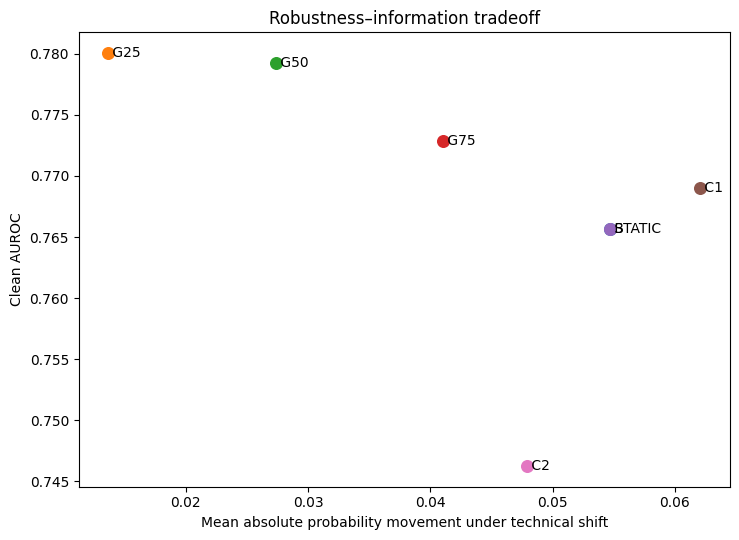

In [51]:

# Figure 1 — robustness / AUROC tradeoff
plot = tradeoff.set_index("model").loc[
    ["B", "G25", "G50", "G75", "STATIC", "C1", "C2"]
]

fig, ax = plt.subplots(figsize=(7.5, 5.5))

for model, row in plot.iterrows():
    ax.scatter(
        row["mean_abs_prob_move"],
        row["AUROC"],
        s=70
    )
    ax.text(
        row["mean_abs_prob_move"],
        row["AUROC"],
        " " + model,
        va="center"
    )

ax.set_xlabel("Mean absolute probability movement under technical shift")
ax.set_ylabel("Clean AUROC")
ax.set_title("Robustness–information tradeoff")
plt.tight_layout()

plt.savefig(
    OUTDIR / "figure_tradeoff_generic_attenuation_vs_trace.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


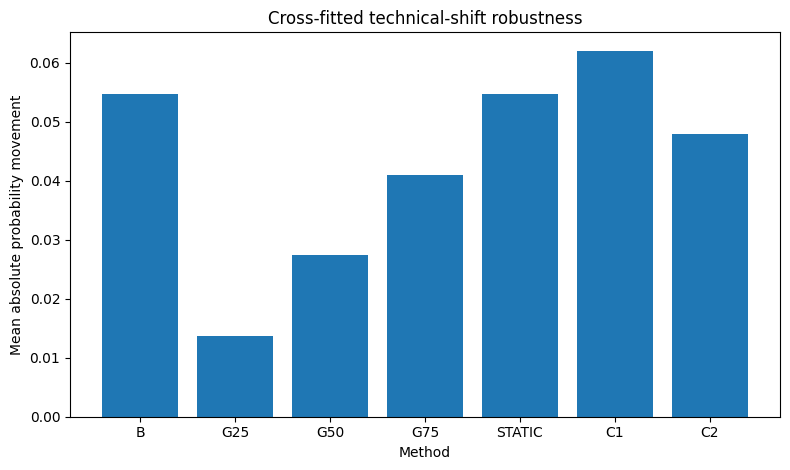

In [52]:

# Figure 2 — movement comparison
ms = movement_summary.set_index("model").loc[
    ["B", "G25", "G50", "G75", "STATIC", "C1", "C2"]
]

fig, ax = plt.subplots(figsize=(8, 4.8))

ax.bar(
    ms.index,
    ms["mean_abs_prob_move"]
)

ax.set_ylabel("Mean absolute probability movement")
ax.set_xlabel("Method")
ax.set_title("Cross-fitted technical-shift robustness")

plt.tight_layout()

plt.savefig(
    OUTDIR / "figure_crossfit_probability_movement.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 18. Aggregate exports

In [53]:

clean_metrics.to_csv(
    OUTDIR / "table_clean_metrics.csv",
    index=False
)

shift_summary.to_csv(
    OUTDIR / "table_shift_summary.csv",
    index=False
)

movement_summary.to_csv(
    OUTDIR / "table_probability_movement.csv",
    index=False
)

movement_bootstrap.to_csv(
    OUTDIR / "table_movement_bootstrap.csv",
    index=False
)

tradeoff.to_csv(
    OUTDIR / "table_robustness_information_tradeoff.csv",
    index=False
)

ranking_summary.to_csv(
    OUTDIR / "table_ranking_stability.csv",
    index=False
)

threshold_by_fold.to_csv(
    OUTDIR / "table_crossfit_thresholds.csv",
    index=False
)

repeat_separation.to_csv(
    OUTDIR / "table_crossfit_repeat_separation.csv",
    index=False
)

print("Aggregate outputs:")
for p in sorted(OUTDIR.glob("*")):
    print(" -", p.name)


Aggregate outputs:
 - figure_crossfit_probability_movement.png
 - figure_tradeoff_generic_attenuation_vs_trace.png
 - manifest.json
 - table_clean_metrics.csv
 - table_crossfit_repeat_separation.csv
 - table_crossfit_thresholds.csv
 - table_movement_bootstrap.csv
 - table_probability_movement.csv
 - table_ranking_stability.csv
 - table_robustness_information_tradeoff.csv
 - table_shift_summary.csv


## 19. Reproducibility manifest

In [54]:

def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()


manifest = {
    "notebook": "24B-REAL-FINAL-STRENGTHENING-V2",
    "seed": SEED,
    "subjects": int(len(df)),
    "outcome": "MCI at ~12-month landmark; future Dementia after landmark through 36 months from baseline",
    "shift_replicates": SHIFT_REPS,
    "repeat_crossfit": {
        "folds": N_FOLDS,
        "threshold_source": "repeat-training subjects",
        "shift_source": "disjoint held-out repeat subjects; full multi-feature ratio vectors preserve cross-feature covariance",
        "maximum_repeat_subject_overlap": int(
            repeat_separation["subject_overlap"].max()
        ),
    },
    "generic_attenuation_controls": generic_gammas,
    "inputs": {
        LANDMARK_PATH.name: sha256_file(LANDMARK_PATH),
        REPEAT_PATH.name: sha256_file(REPEAT_PATH),
    },
}

with open(
    OUTDIR / "manifest.json",
    "w"
) as f:
    json.dump(
        manifest,
        f,
        indent=2
    )

manifest


{'notebook': '24B-REAL-FINAL-STRENGTHENING-V2',
 'seed': 2027,
 'subjects': 199,
 'outcome': 'MCI at ~12-month landmark; future Dementia after landmark through 36 months from baseline',
 'shift_replicates': 100,
 'repeat_crossfit': {'folds': 5,
  'threshold_source': 'repeat-training subjects',
  'shift_source': 'disjoint held-out repeat subjects; full multi-feature ratio vectors preserve cross-feature covariance',
  'maximum_repeat_subject_overlap': 0},
 'generic_attenuation_controls': {'G25': 0.25, 'G50': 0.5, 'G75': 0.75},
 'inputs': {'TRACE_ADNI1_landmark12_REAL.csv': '7ea99227785f876a0ae823e209d390fe98f335d534e3f36165f2e847f4705203',
  'TRACE_ADNI1_repeat_pairs_REAL.csv': '3a600b5cf11df11d2511e51ebbc933eed8be3d04305b7b281271d058c37ab926'}}

## 20. FINAL STRENGTHENING READINESS SUMMARY

In [55]:

print("============================================================")
print("24B V2 FINAL STRENGTHENING READINESS SUMMARY")
print("============================================================")

print("Landmark subjects:", len(df))
print("Future converters pMCI12:", int(y.sum()))
print("Stable sMCI12:", int((1-y).sum()))

print("\nTEMPORAL LANDMARK CHECK")
print("All included subjects have LABEL_12_36 and therefore passed the strict")
print("12-month MCI landmark + follow-up eligibility rules in 24A.")

print("\nCROSS-FIT REPEAT SEPARATION")
display(repeat_separation)

print("\nCLEAN MODEL / ATTENUATION METRICS")
display(clean_metrics.round(4))

print("\nSHIFTED SUMMARY")
display(shift_summary.round(4))

print("\nPRIMARY PROBABILITY-MOVEMENT ENDPOINT")
display(movement_summary.round(5))

print("\nPAIRED BOOTSTRAP")
print("Negative C2-comparator differences favor TRACE C2.")
display(movement_bootstrap.round(5))

print("\nROBUSTNESS–INFORMATION TRADEOFF")
display(tradeoff.round(5))

print("\nRANKING STABILITY")
display(ranking_summary.round(4))

print("\nREADINESS CHECKS")

checks = {
    "strict_12m_landmark_outcome": df["LABEL_12_36"].notna().all(),
    "both_outcome_classes_present": df["y"].nunique() == 2,
    "crossfit_repeat_subject_overlap_zero":
        (repeat_separation["subject_overlap"] == 0).all(),
    "outer_test_rid_excluded_from_repeat_calibration":
        (repeat_separation["outer_test_overlap_calibration"] == 0).all(),
    "outer_test_rid_excluded_from_repeat_shift_bank":
        (repeat_separation["outer_test_overlap_shift"] == 0).all(),
    "covariance_preserving_full_pair_shifts":
        (repeat_separation["complete_shift_vectors"] >= 5).all(),
    "heldout_repeat_shift_bank_each_fold":
        (repeat_separation["shift_pairs"] > 0).all(),
    "generic_G25_G50_G75_controls_present":
        all(x in all_clean for x in ["G25","G50","G75"]),
    "static_feature_reliability_baseline_present":
        "STATIC" in all_clean,
    "trace_C2_present": "C2" in all_clean,
    "paired_bootstrap_completed":
        len(movement_bootstrap) == len(comparisons),
}

for name, passed in checks.items():
    print(
        f"{name}: {'PASS' if passed else 'CHECK'}"
    )

print("\nINTERPRETATION RULE")
print("If generic attenuation or STATIC matches/exceeds C2, do not claim TRACE-specific")
print("robustness superiority. Report the attenuation control transparently.")
print("If C2 provides a better robustness–information tradeoff, that supports")
print("patient-specific reliability control beyond generic shrinkage.")


24B V2 FINAL STRENGTHENING READINESS SUMMARY
Landmark subjects: 199
Future converters pMCI12: 76
Stable sMCI12: 123

TEMPORAL LANDMARK CHECK
All included subjects have LABEL_12_36 and therefore passed the strict
12-month MCI landmark + follow-up eligibility rules in 24A.

CROSS-FIT REPEAT SEPARATION


,outer_fold,calibration_repeat_subjects,shift_repeat_subjects,calibration_pairs,shift_pairs,subject_overlap,outer_test_overlap_calibration,outer_test_overlap_shift,complete_shift_vectors
0,0,42,10,50,17,0,0,0,17
1,1,40,8,49,9,0,0,0,9
2,2,40,10,48,13,0,0,0,13
3,3,43,9,53,11,0,0,0,11
4,4,37,10,51,11,0,0,0,11



CLEAN MODEL / ATTENUATION METRICS


,model,AUROC,AUPRC,Brier,ECE,CalibrationIntercept,CalibrationSlope,ConfidentWrongRate
0,A,0.7791,0.6738,0.1856,0.0814,-0.1590,0.9725,0.0302
1,B,0.7656,0.6659,0.1883,0.0742,-0.1963,0.8468,0.0402
2,G25,0.7801,0.6797,0.1843,0.1016,-0.1509,0.9949,0.0302
3,G50,0.7792,0.6819,0.1844,0.0819,-0.1556,0.9783,0.0251
4,G75,0.7729,0.6753,0.1857,0.0703,-0.1715,0.9271,0.0251
5,STATIC,0.7656,0.6659,0.1883,0.0742,-0.1963,0.8468,0.0402
6,C1,0.7690,0.6837,0.1862,0.0572,-0.2769,0.6348,0.0452
7,C2,0.7463,0.6433,0.1964,0.0378,-0.2172,0.7789,0.0452



SHIFTED SUMMARY


...


ROBUSTNESS–INFORMATION TRADEOFF


,model,AUROC,Brier,ECE,mean_abs_prob_move
0,A,0.77910,0.18563,0.08145,0.00000
1,B,0.76562,0.18833,0.07417,0.05471
2,G25,0.78006,0.18434,0.10164,0.01368
3,G50,0.77920,0.18437,0.08187,0.02735
4,G75,0.77289,0.18570,0.07034,0.04103
5,STATIC,0.76562,0.18833,0.07417,0.05471
6,C1,0.76904,0.18615,0.05720,0.06208
7,C2,0.74626,0.19641,0.03784,0.04790



RANKING STABILITY


,model,spearman_mean,spearman_p025,top20_mean,top20_p025
0,A,1.0000,1.0000,1.0000,1.0000
1,B,0.9329,0.9099,0.8862,0.8250
2,C1,0.8196,0.7500,0.7425,0.6500
3,C2,0.9231,0.8873,0.8585,0.7869
4,G25,0.9935,0.9906,0.9695,0.9369
5,G50,0.9776,0.9701,0.9415,0.8869
6,G75,0.9558,0.9415,0.9125,0.8500
7,STATIC,0.9329,0.9099,0.8862,0.8250



READINESS CHECKS
strict_12m_landmark_outcome: PASS
both_outcome_classes_present: PASS
crossfit_repeat_subject_overlap_zero: PASS
outer_test_rid_excluded_from_repeat_calibration: PASS
outer_test_rid_excluded_from_repeat_shift_bank: PASS
covariance_preserving_full_pair_shifts: PASS
heldout_repeat_shift_bank_each_fold: PASS
generic_G25_G50_G75_controls_present: PASS
static_feature_reliability_baseline_present: PASS
trace_C2_present: PASS
paired_bootstrap_completed: PASS

INTERPRETATION RULE
If generic attenuation or STATIC matches/exceeds C2, do not claim TRACE-specific
robustness superiority. Report the attenuation control transparently.
If C2 provides a better robustness–information tradeoff, that supports
patient-specific reliability control beyond generic shrinkage.
